# Лабораторная работа №3
## Понижение размерности

**Датасет:** Water Potability

Данный датасет содержит данные о качестве воды с физическими и химическими характеристиками. Цель - определить пригодность воды для питья на основе различных параметров.

In [2]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn umap-learn

  Obtaining dependency information for umap-learn from https://files.pythonhosted.org/packages/1b/98/f63318ccbe75c810011fe9233884c5d348d94d90005de1b79e5f93bef9c0/umap_learn-0.5.12-py3-none-any.whl.metadata
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Obtaining dependency information for numba>=0.51.2 from https://files.pythonhosted.org/packages/79/37/14a4579049c1eb673afd0de0cb4842982acd55b9ce2643e763db858bcea0/numba-0.65.1-cp313-cp313-macosx_12_0_arm64.whl.metadata
  Using cached numba-0.65.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (2.9 kB)
  Obtaining dependency information for pynndescent>=0.5 from https://files.pythonhosted.org/packages/b2/e6/94145d714402fd5ade00b5661f2d0ab981219e07f7db9bfa16786cdb9c04/pynndescent-0.6.0-py3-none-any.whl.metadata
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/16/e1/3079a9ff9b8e11b846c6ac5c8b5bfb7ff225eee721825310c91

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [20]:
# Загрузка данных
df = pd.read_csv('../data/water_potability_cleaned.csv')

numeric_features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
                   'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

feature_labels = {
    'ph': 'pH',
    'Hardness': 'Жесткость',
    'Solids': 'Твердые вещества',
    'Chloramines': 'Хлорамины',
    'Sulfate': 'Сульфат',
    'Conductivity': 'Проводимость',
    'Organic_carbon': 'Органический углерод',
    'Trihalomethanes': 'Тригалометаны',
    'Turbidity': 'Мутность'
}
df_numeric = df[numeric_features].dropna()

print(f"Размер датасета: {df_numeric.shape}")
print(f"Признаки: {numeric_features}")
print(f"Пропущенные значения по признакам:")
print(df[numeric_features].isnull().sum())

Размер датасета: (4190, 9)
Признаки: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
Пропущенные значения по признакам:
ph                   0
Hardness             0
Solids               0
Chloramines         96
Sulfate            507
Conductivity         0
Organic_carbon      26
Trihalomethanes    222
Turbidity           59
dtype: int64


---
# Задание 1. Геометрия данных в пространстве признаков

In [21]:
# 1. Количество объектов и признаков
print(f"Количество объектов: {df_numeric.shape[0]}")
print(f"Количество признаков: {df_numeric.shape[1]}")
print(f"Признаки: {list(df_numeric.columns)}")


Количество объектов: 4190
Количество признаков: 9
Признаки: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


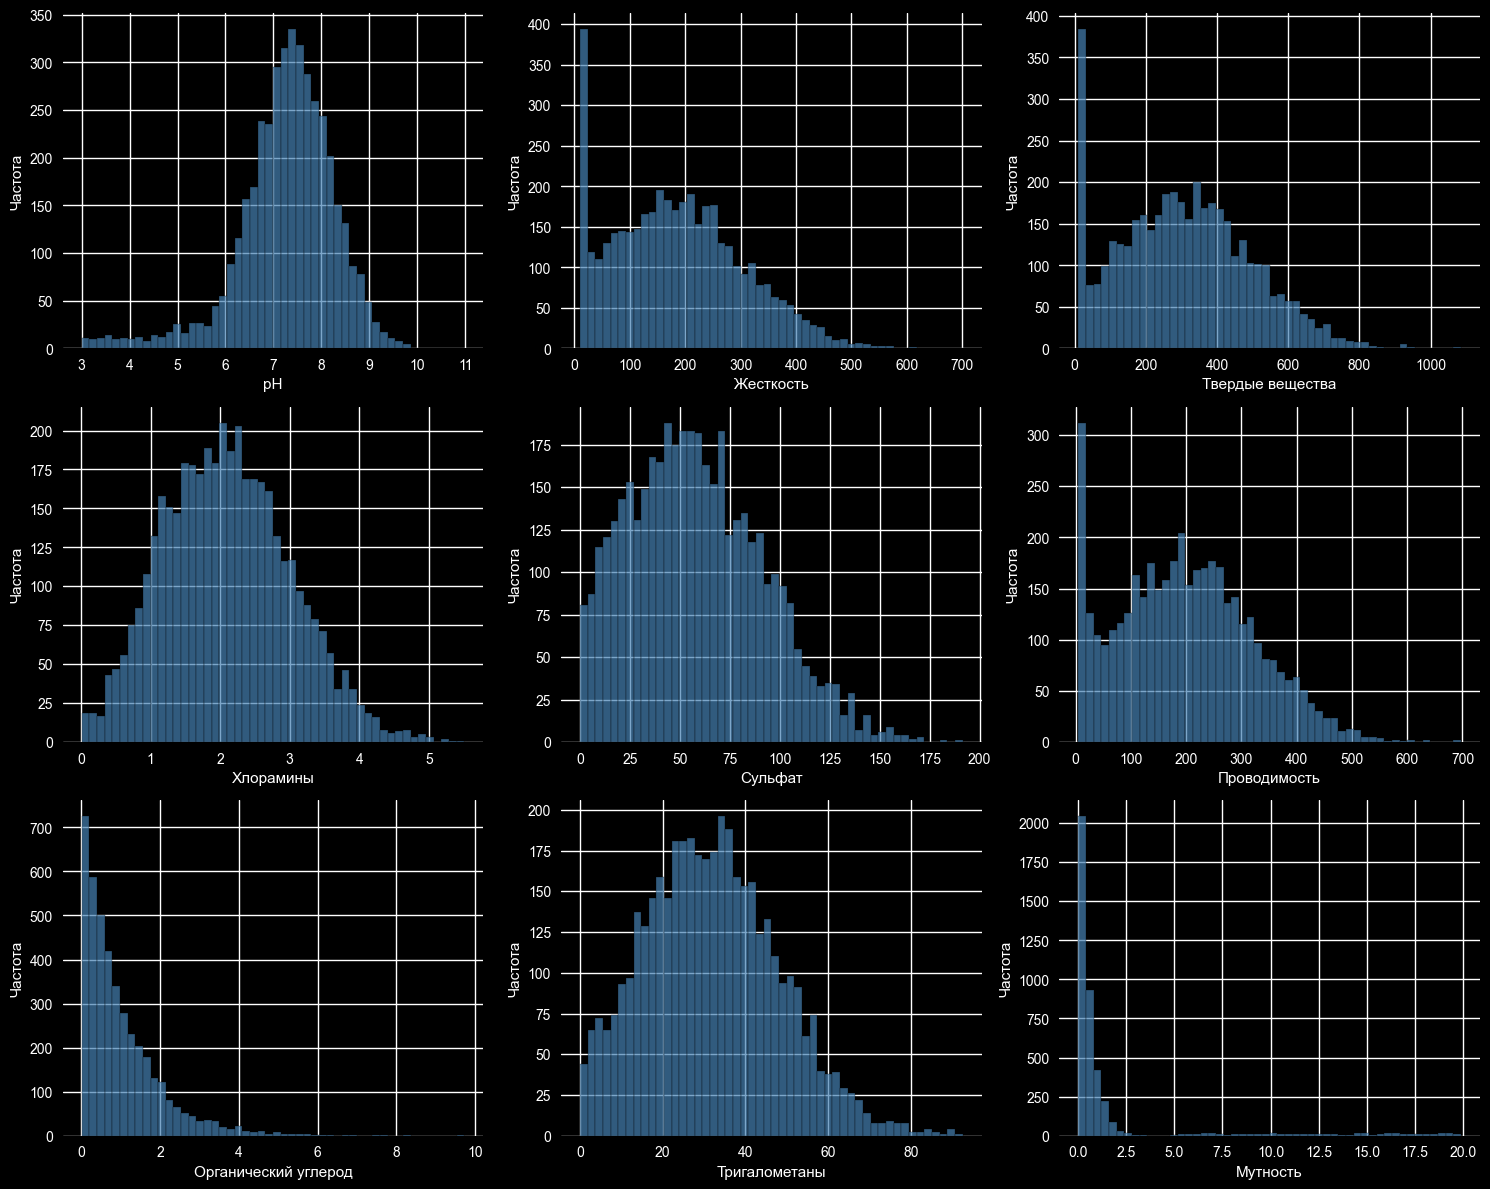

In [22]:
# 2. Гистограммы
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].hist(df_numeric[col], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i].set_xlabel(feature_labels[col])

    axes[i].set_ylabel('Частота')
plt.tight_layout()
plt.show()

## Общие выводы по распределениям признаков
Признаки делятся на две чёткие группы:
1) pH, Сульфат, Хлорамины, Тригалометаны близки к нормальному (симметричному) распределению.
2) Жёсткость, Твёрдые вещества, Проводимость, Органический углерод, Мутность имеют сильную правую асимметрию с длинными «хвостами» и пиком у низких значений.

# Задание 3. Интерпретация главных компонент

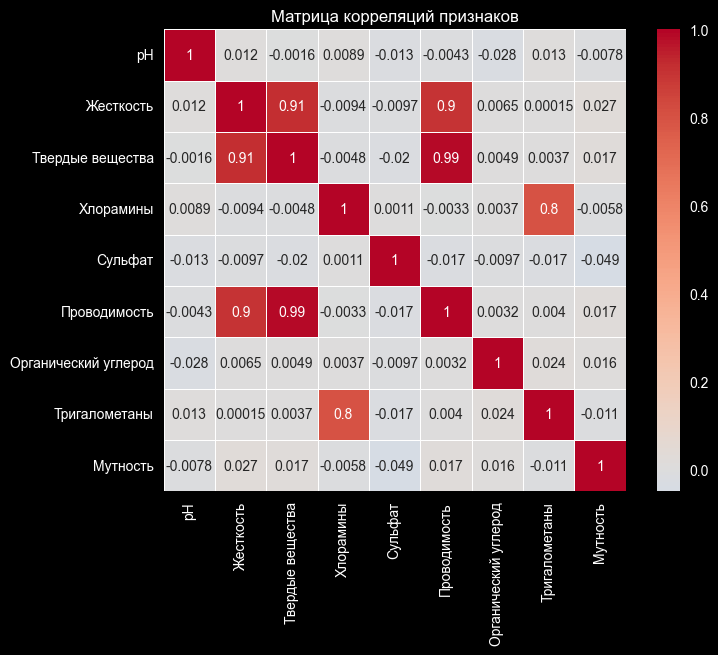

Выводы по матрице корреляций:

Сильные положительные корреляции:

Solids и Conductivity: 0.99 (почти идеальная корреляция)
Общее содержание твердых веществ и электропроводность воды практически линейно зависимы

Hardness и Solids: 0.91 (очень сильная корреляция)
Жесткость воды тесно связана с общим содержанием твердых веществ

Hardness и Conductivity: 0.9 (очень сильная корреляция)
Жесткость и проводимость сильно взаимосвязаны

Chloramines и Trihalomethanes: 0.8 (сильная корреляция)
Хлорамины и тригалометаны коррелируют ( т.к. тригалометаны образуются при хлорировании)


In [54]:
corr_matrix = df_numeric.corr()

corr_matrix.columns = [feature_labels[col] for col in corr_matrix.columns]
corr_matrix.index = [feature_labels[col] for col in corr_matrix.index]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Матрица корреляций признаков')
plt.show()

print("Выводы по матрице корреляций:")
print()
print("Сильные положительные корреляции:")
print()
print("Solids и Conductivity: 0.99 (почти идеальная корреляция)")
print("Общее содержание твердых веществ и электропроводность воды практически линейно зависимы")
print()
print("Hardness и Solids: 0.91 (очень сильная корреляция)")
print("Жесткость воды тесно связана с общим содержанием твердых веществ")
print()
print("Hardness и Conductivity: 0.9 (очень сильная корреляция)")
print("Жесткость и проводимость сильно взаимосвязаны")
print()
print("Chloramines и Trihalomethanes: 0.8 (сильная корреляция)")
print("Хлорамины и тригалометаны коррелируют ( т.к. тригалометаны образуются при хлорировании)")



---
# Задание 2. Реализация PCA


Объектов: 4190
Признаков: 9

Сравнение с sklearn:
  PC1 корреляция: 1.000000
  PC2 корреляция: 1.000000

Вклад компонент в дисперсию:
  Компонента 1: 31.91% (суммарно: 31.91%)
  Компонента 2: 20.01% (суммарно: 51.92%)
  Компонента 3: 11.72% (суммарно: 63.64%)
  Компонента 4: 11.40% (суммарно: 75.04%)
  Компонента 5: 10.78% (суммарно: 85.82%)
  Компонента 6: 10.52% (суммарно: 96.34%)
  Компонента 7: 2.22% (суммарно: 98.56%)
  Компонента 8: 1.30% (суммарно: 99.86%)
  Компонента 9: 0.14% (суммарно: 100.00%)


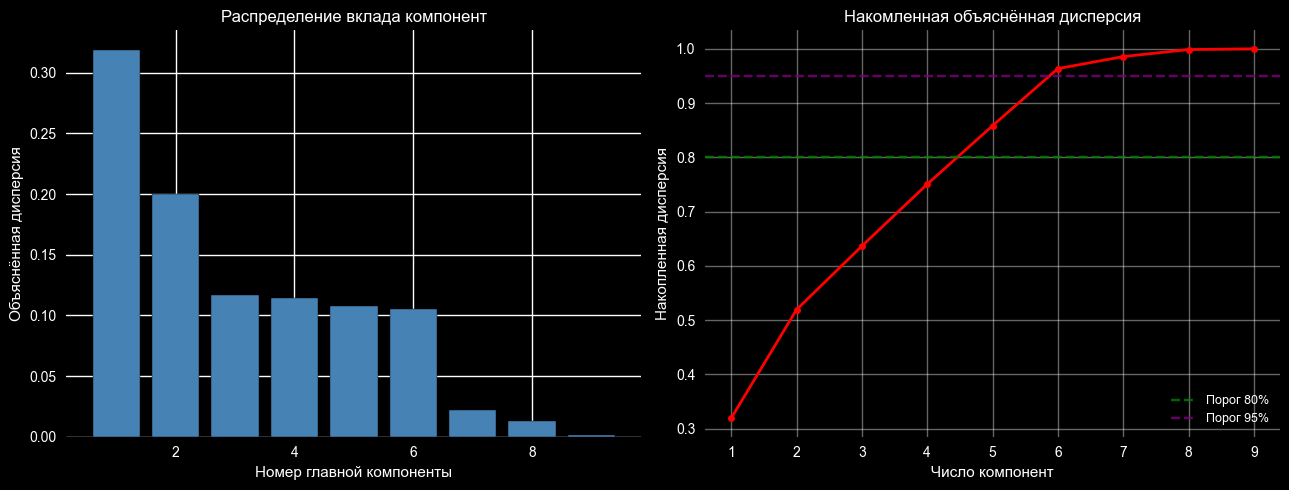


► Для 80% дисперсии достаточно 5 компонент (85.8%)
► Для 95% дисперсии требуется 6 компонент (96.3%)


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_std = (df_numeric - np.mean(df_numeric, axis=0)) / np.std(df_numeric, axis=0)

cov_mat = np.cov(X_std, rowvar=False)
eig_vals, eig_vecs = np.linalg.eigh(cov_mat)

sort_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sort_idx]
eig_vecs = eig_vecs[:, sort_idx]

var_ratio = eig_vals / eig_vals.sum()
var_cumsum = np.cumsum(var_ratio)

def project_pca(data, vectors, n_comp):
    return np.dot(data, vectors[:, :n_comp])

print(f"\nОбъектов: {df_numeric.shape[0]}")
print(f"Признаков: {df_numeric.shape[1]}")

X_our_proj = project_pca(X_std, eig_vecs, 2)

print("\nСравнение с sklearn:")
pca_ref = PCA()
X_transformed_ref = pca_ref.fit_transform(X_std)

c1 = np.corrcoef(X_our_proj[:, 0], X_transformed_ref[:, 0])[0, 1]
c2 = np.corrcoef(X_our_proj[:, 1], X_transformed_ref[:, 1])[0, 1]
print(f"  PC1 корреляция: {np.abs(c1):.6f}")
print(f"  PC2 корреляция: {np.abs(c2):.6f}")

print("\nВклад компонент в дисперсию:")
for idx, (var, cum) in enumerate(zip(var_ratio, var_cumsum), start=1):
    print(f"  Компонента {idx}: {var*100:.2f}% (суммарно: {cum*100:.2f}%)")

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].bar(np.arange(1, len(var_ratio)+1), var_ratio, color='steelblue', edgecolor='black')
axs[0].set_xlabel('Номер главной компоненты')
axs[0].set_ylabel('Объяснённая дисперсия')
axs[0].set_title('Распределение вклада компонент')

axs[1].plot(np.arange(1, len(var_cumsum)+1), var_cumsum, 'ro-', linewidth=2, markersize=5)
axs[1].axhline(0.80, color='green', ls='--', alpha=0.8, label='Порог 80%')
axs[1].axhline(0.95, color='purple', ls='--', alpha=0.8, label='Порог 95%')
axs[1].set_xlabel('Число компонент')
axs[1].set_ylabel('Накопленная дисперсия')
axs[1].set_title('Накомленная объяснённая дисперсия')
axs[1].legend(fontsize=9)
axs[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

k_80 = np.where(var_cumsum >= 0.80)[0][0] + 1
k_95 = np.where(var_cumsum >= 0.95)[0][0] + 1

print(f"\n► Для 80% дисперсии достаточно {k_80} компонент ({var_cumsum[k_80-1]*100:.1f}%)")
print(f"► Для 95% дисперсии требуется {k_95} компонент ({var_cumsum[k_95-1]*100:.1f}%)")

## Выводы по 3 заданию:
1) Первые две компоненты сохраняют лишь половину информации — это подтверждает, что признаки слабо коррелируют и не «схлопываются» в одну линию.
2)  Дисперсия распределена относительно равномерно: даже 6-я компонента вносит >10% вклада. Это значит, что почти все исходные признаки несут уникальную информацию.

# Задание 4. Интерпретация главных компонент


In [29]:
features = df_numeric.columns.tolist()
loadings = pd.DataFrame(eig_vecs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=features)
loadings_ru = loadings.copy()
loadings_ru.index = [feature_labels[col] for col in features]

print("Коэффициенты признаков в главных компонентах")
print(loadings_ru.round(3))

print("\nПризнаки с наибольшим вкладом в каждую компоненту:")
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc}:")
    top3 = loadings_ru[pc].abs().sort_values(ascending=False).head(3)
    for name_ru in top3.index:
        original_col = [col for col, label in feature_labels.items() if label == name_ru][0]
        val = loadings.loc[original_col, pc]
        print(f"- {name_ru}: {val:+.3f}")

print("\n1. Какие признаки больше всего влияют на первую компоненту?")
top5_pc1 = loadings_ru['PC1'].abs().sort_values(ascending=False).head(5)
for name_ru in top5_pc1.index:
    original_col = [col for col, label in feature_labels.items() if label == name_ru][0]
    val = loadings.loc[original_col, 'PC1']
    print(f"- {name_ru}: {val:+.3f}")

print("\n2. Можно ли интерпретировать первую компоненту?")
print("Похоже, PC1 отражает общую минерализацию воды: твёрдые вещества, электропроводность, жёсткость и сульфаты")

print("\n3. Есть ли признаки, которые практически не влияют на первые компоненты?")
total_influence = loadings_ru.abs().sum(axis=1)
weakest_ru = total_influence.idxmin()
original_col = [col for col, label in feature_labels.items() if label == weakest_ru][0]

print(f"   Признак с наименьшим влиянием: {weakest_ru}")
print(f"   Его веса в первых трех компонентах:")
for i in range(3):
    val = loadings.loc[original_col, f'PC{i+1}']
    print(f"      PC{i+1}: {val:+.3f}")

Коэффициенты признаков в главных компонентах
                        PC1    PC2    PC3
pH                   -0.002  0.019  0.141
Жесткость            -0.566 -0.001  0.013
Твердые вещества     -0.584  0.003  0.013
Хлорамины             0.005  0.706  0.012
Сульфат               0.015 -0.014  0.625
Проводимость         -0.581  0.004  0.015
Органический углерод -0.005  0.024 -0.371
Тригалометаны        -0.000  0.707 -0.004
Мутность             -0.019 -0.014 -0.672

Признаки с наибольшим вкладом в каждую компоненту:

PC1:
- Твердые вещества: -0.584
- Проводимость: -0.581
- Жесткость: -0.566

PC2:
- Тригалометаны: +0.707
- Хлорамины: +0.706
- Органический углерод: +0.024

PC3:
- Мутность: -0.672
- Сульфат: +0.625
- Органический углерод: -0.371

1. Какие признаки больше всего влияют на первую компоненту?
- Твердые вещества: -0.584
- Проводимость: -0.581
- Жесткость: -0.566
- Мутность: -0.019
- Сульфат: +0.015

2. Можно ли интерпретировать первую компоненту?
Похоже, PC1 отражает общую минерали

# Задание 4. Визуализация данных

Для сравнения выберем исходные признаки: 'Hardness' и 'ph'


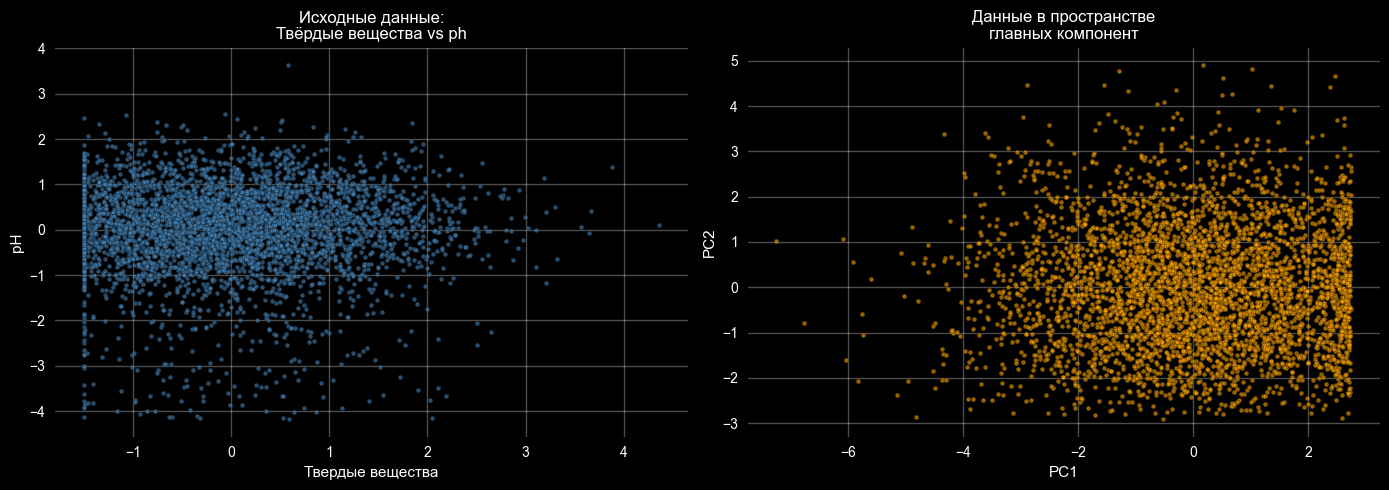


Доля объяснённой дисперсии:
PC1: 31.91%
PC2: 20.01%
Суммарно первые 2 компоненты: 51.92%


In [40]:

X_std_array = X_std.values if hasattr(X_std, 'values') else X_std

X_pca = project_pca(X_std_array, eig_vecs, 2)

feat1_idx = list(df_numeric.columns).index('Hardness')
feat2_idx = list(df_numeric.columns).index('ph')

print(f"Для сравнения выберем исходные признаки: '{df_numeric.columns[feat1_idx]}' и '{df_numeric.columns[feat2_idx]}'")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(
    X_std_array[:, feat1_idx],
    X_std_array[:, feat2_idx],
    alpha=0.6, s=12, c='steelblue', edgecolors='black', linewidth=0.3
)
ax1.set_xlabel(feature_labels['Solids'], fontsize=11)
ax1.set_ylabel(feature_labels['ph'], fontsize=11)
ax1.set_title('Исходные данные:\nТвёрдые вещества vs ph', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.scatter(
    X_pca[:, 0], X_pca[:, 1],
    alpha=0.6, s=12, c='orange', edgecolors='black', linewidth=0.3
)
ax2.set_xlabel('PC1', fontsize=11)
ax2.set_ylabel('PC2', fontsize=11)
ax2.set_title('Данные в пространстве\nглавных компонент', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nДоля объяснённой дисперсии:")
print(f"PC1: {var_ratio[0]*100:.2f}%")
print(f"PC2: {var_ratio[1]*100:.2f}%")
print(f"Суммарно первые 2 компоненты: {(var_ratio[0] + var_ratio[1])*100:.2f}%")

Ответы на вопросы
1. Улучшилась ли визуализация после PCA?
Нет тк точки уже выглядели как облако из-за отсутствия корреляции. PCA не «сжал» их в линию, а перераспределил дисперсию по новым осям. Это позволило:
Увидеть, что ни одно направление не доминирует (подтверждение независимости признаков)
Оценить, сколько информации теряется при проекции (осталось 52%)

2. Почему в пространстве главных компонент структура может быть заметнее?
Когда признаки коррелируют, PCA «схлопывает» избыточную информацию в одну ось, делая паттерны очевидными.



# Задание 5. Нелинейные методы снижения размерности

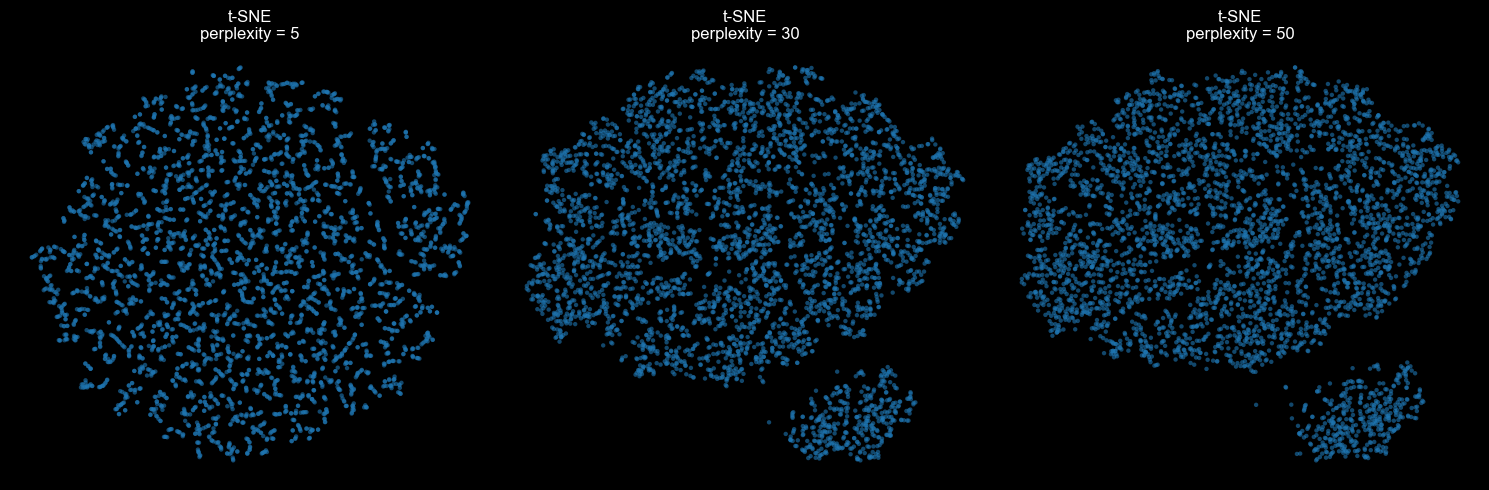

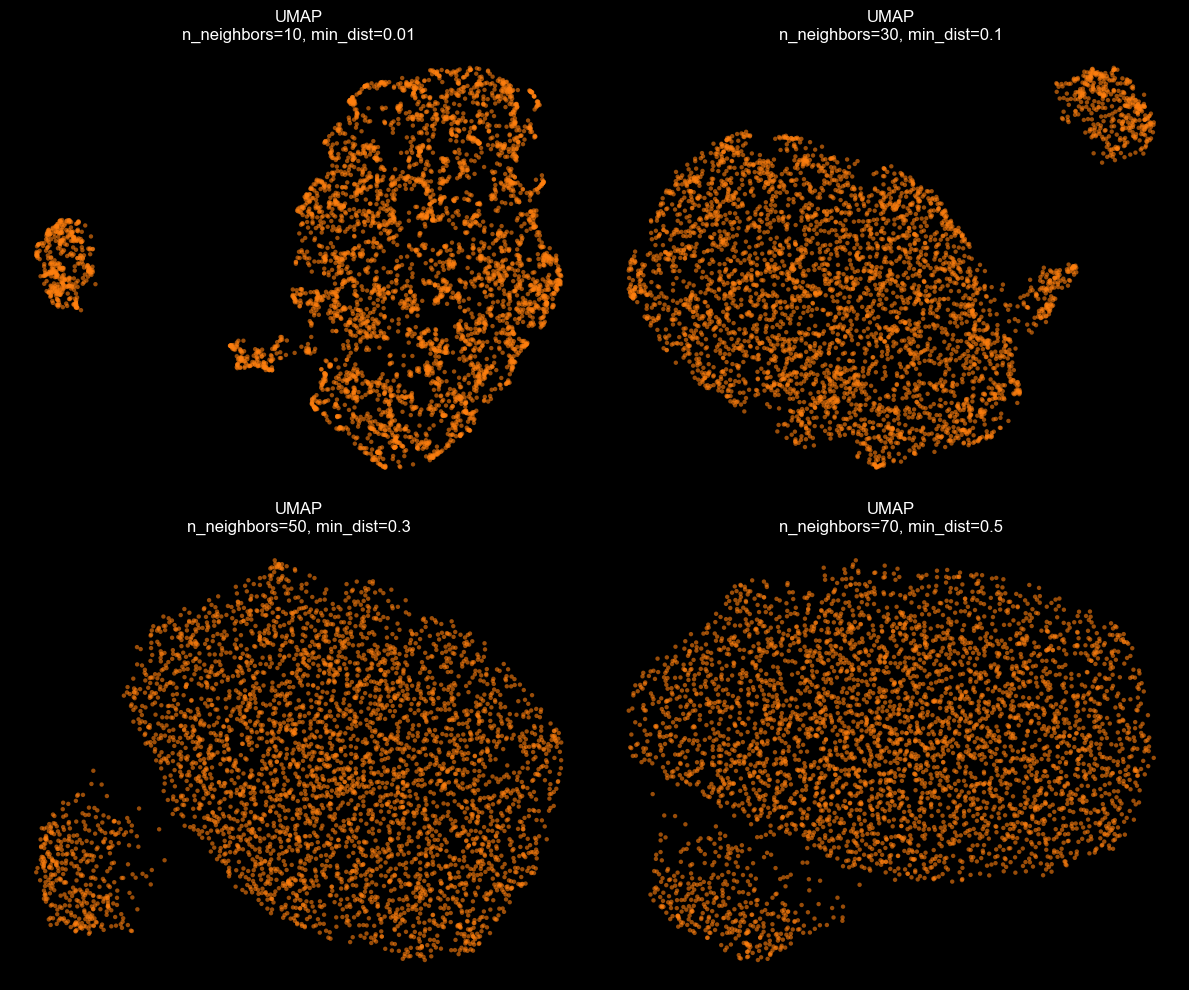

In [45]:

from sklearn.manifold import TSNE
import umap
import numpy as np
import matplotlib.pyplot as plt

n_samples = X_std_array.shape[0]
sample_size = min(15000, n_samples)

np.random.seed(42)
sample_idx = np.random.choice(n_samples, sample_size, replace=False)
X_sample = X_std_array[sample_idx]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, perp in enumerate([5, 30, 50]):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=42,
        max_iter=1000,
        n_jobs=-1
    )
    X_tsne = tsne.fit_transform(X_sample)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=10, edgecolors='none', c='tab:blue')
    axes[i].set_title(f't-SNE\nperplexity = {perp}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

params = [(10, 0.01), (30, 0.1), (50, 0.3), (70, 0.5)]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (n_neighbors, min_dist) in enumerate(params):
    n_neighbors_adj = min(n_neighbors, sample_size - 1)
    if n_neighbors != n_neighbors_adj:
        print(f"⚠️ UMAP: n_neighbors={n_neighbors} → скорректировано до {n_neighbors_adj}")

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors_adj,
        min_dist=min_dist,
        random_state=42
    )
    X_umap = reducer.fit_transform(X_sample)
    axes[i].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, s=10, edgecolors='none', c='tab:orange')
    axes[i].set_title(f'UMAP\nn_neighbors={n_neighbors_adj}, min_dist={min_dist}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

## Выводы по 5 заданию:

1. Отсутствие чёткой кластерной структуры
Большинство точек образуют единое облако без явного разделения на группы
Это подтверждает выводы PCA: признаки слабо коррелируют и не образуют дискретных классов
2. Наличие аномалий
При perplexity=30, 50 (t-SNE) и n_neighbors=30, 50 (UMAP) стабильно выделяется небольшой отдельный кластер (выбросы)
Это объекты с экстремальными характеристиками воды
3. Сравнение методов
t-SNE: Показывает общую форму, но чувствителен к perplexity
UMAP: Лучше сохраняет глобальную структуру, стабильнее выделяет выбросы, работает быстрее

---
# Задание 6. Исследование степени сжатия данных

Анализ реконструкции PCA:
k	MSE
---------------
2	0.480842
4	0.249589
5	0.141752
7	0.014359
9	0.000000


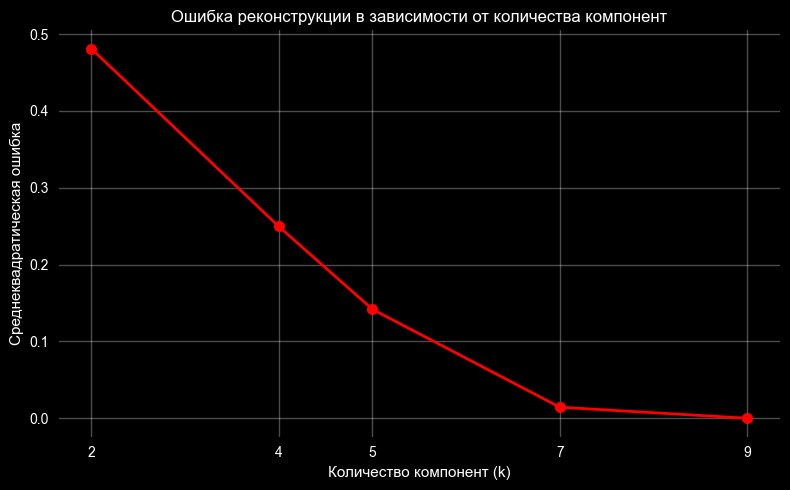


Анализ:
- СКО уменьшается при использовании большего количества компонент
- При использовании всех 9 компонент СКО близка к 0 — полное восстановление данных
- Кривая показывает компромисс между снижением размерности и потерей информации


In [58]:
def project_pca(data, eigenvectors, n_components):
    return np.dot(data, eigenvectors[:, :n_components])

def reconstruct_pca(data, eigenvectors, n_components):
    X_pca = project_pca(data, eigenvectors, n_components)
    X_reconstructed = np.dot(X_pca, eigenvectors[:, :n_components].T)
    return X_reconstructed

# Убедимся, что X_scaled доступен и совпадает с X_std_array
X_scaled = X_std.values if hasattr(X_std, 'values') else X_std

k_values = [2, 4, 5, 7, 9]
reconstruction_errors = []

print("Анализ реконструкции PCA:")
print("k\tMSE")
print("-"*15)

for k in k_values:
    X_reconstructed = reconstruct_pca(X_scaled, eig_vecs, k)
    mse = np.mean((X_scaled - X_reconstructed) ** 2)
    reconstruction_errors.append(mse)
    print(f"{k}\t{mse:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, reconstruction_errors, 'o-', color='red', linewidth=2, markersize=8)
plt.xlabel('Количество компонент (k)')
plt.ylabel('Среднеквадратическая ошибка')
plt.title('Ошибка реконструкции в зависимости от количества компонент')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print("\nАнализ:")
print("- СКО уменьшается при использовании большего количества компонент")
print("- При использовании всех 9 компонент СКО близка к 0 — полное восстановление данных")
print("- Кривая показывает компромисс между снижением размерности и потерей информации")

### 6.5 Интерпретация результатов

**1. Почему при малом числе компонент ошибка восстановления большая?**

При малом k сохраняются только направления наибольшей дисперсии, а остальные отбрасываются. Это приводит к потере части информации, особенно мелких деталей и шумов, которые могут быть важны для точного восстановления.

**2. Почему увеличение числа компонент уменьшает ошибку?**

Каждая дополнительная компонента возвращает часть утерянной информации. Чем больше компонент используется, тем точнее восстановление, так как сохраняется больше исходных измерений.

**3. Можно ли полностью восстановить исходные данные при использовании всех компонент?**

Да. Если взять k равным исходной размерности, PCA становится просто поворотом системы координат без потери информации. В этом случае MSE = 0.

**4. Как это связано с объяснённой дисперсией PCA?**

Ошибка восстановления и объяснённая дисперсия связаны обратной зависимостью: чем больше дисперсии сохранено, тем меньше MSE (MSE = 1 - "накопленная дисперсия").

**5. Как можно определить разумное число компонент, при котором данные уже хорошо описаны, но размерность существенно меньше?**

Существует несколько подходов: метод колена — выбор k в точке излома графика ошибки; пороговый метод — выбор k, объясняющего 90-95% дисперсии. В данном случае оптимальным является k = 8-10, так как при этом достигается хорошее качество восстановления при значительном снижении размерности.

---
# Задание 7. Итоговый анализ

## 7. Итоговый анализ

**1. Какую роль играет снижение размерности в анализе данных?**

Снижение размерности позволяет упростить данные, удалить шум и избыточную информацию, ускорить обучение моделей и визуализировать многомерные данные на плоскости. Это помогает выявить скрытую структуру и закономерности, которые не видны в исходном пространстве признаков.

**2. Всегда ли уменьшение размерности полезно?**

Нет. Уменьшение размерности всегда сопровождается потерей информации. Если данные уже имеют низкую размерность или каждый признак важен для анализа, сжатие может привести к неверным выводам.

**3. В каких случаях линейные методы могут работать хуже нелинейных?**

Линейные методы (PCA) плохо работают, когда данные имеют сложную нелинейную структуру, например, точки образуют сложные нелинейные формы, лежат на изогнутой поверхности. В таких случаях t-SNE и UMAP лучше сохраняют локальную структуру и разделяют кластеры.

**4. Какие преимущества и ограничения есть у методов PCA, t-SNE и UMAP?**

| Метод | Преимущества | Ограничения                                                                              |
|-------|--------------|------------------------------------------------------------------------------------------|
| PCA | Быстрый, сохраняет глобальную структуру, легко интерпретировать компоненты | Только линейные преобразования, плохо разделяет нелинейные кластеры |
| t-SNE | Отлично разделяет кластеры, сохраняет локальную структуру | Медленный, чувствителен к perplexity, не сохраняет глобальные расстояния, стохастический |
| UMAP | Быстрее t-SNE, лучше сохраняет глобальную структуру, меньше чувствителен к параметрам | Сложнее интерпретировать, стохастический |